# 02 — Model Training & Validation
**Project**: Defect Detection in Gear & Bearing using Deep Learning

This notebook trains a **ResNet-50** classifier on the spectrogram images:
1. Load spectrograms using PyTorch `ImageFolder`
2. Set up ResNet-50 with Transfer Learning
3. Phase 1: Train FC layer only (feature extraction)
4. Phase 2: Fine-tune layer4 + FC
5. Evaluate with confusion matrix and classification report

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = os.path.abspath('..')
DATA_DIR = os.path.join(BASE_DIR, 'data')
MODEL_DIR = os.path.join(BASE_DIR, 'models')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')
print(f'PyTorch version: {torch.__version__}')

Training on: cpu
PyTorch version: 2.3.1+cpu


## Step 1: Data Loading with ImageFolder

In [2]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'validation': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
    for x in ['train', 'validation']
}
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=16, shuffle=(x == 'train'), num_workers=0)
    for x in ['train', 'validation']
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'validation']}
class_names = image_datasets['train'].classes

print(f'Classes: {class_names}')
print(f'Training samples:   {dataset_sizes["train"]}')
print(f'Validation samples: {dataset_sizes["validation"]}')

Classes: ['ball_fault', 'broken_tooth', 'healthy_gear', 'inner_race_fault', 'normal_bearing', 'outer_race_fault']
Training samples:   1260
Validation samples: 270


## Step 2: Visualize a Training Batch

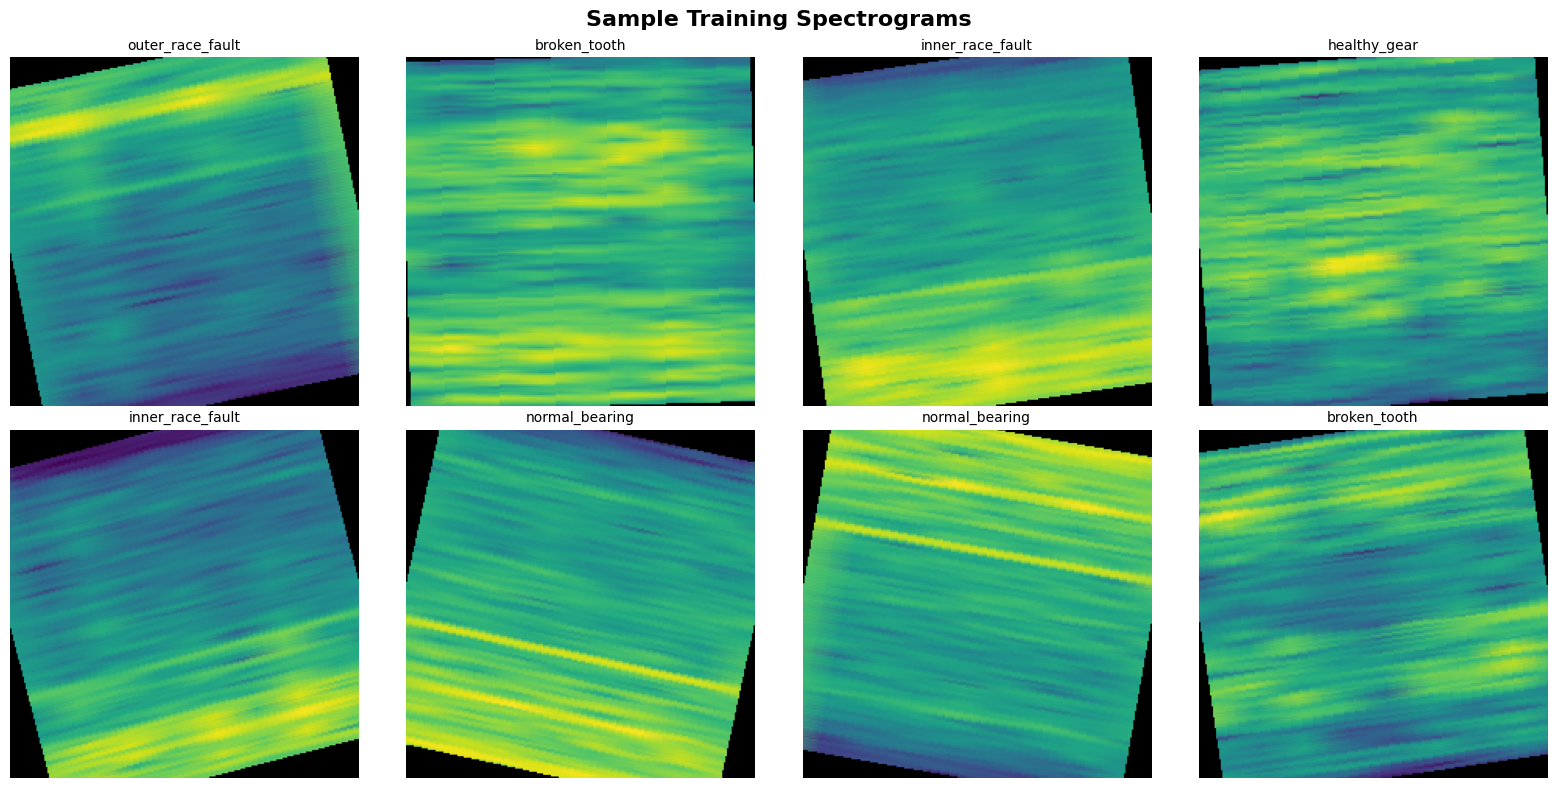

Training batch visualized.


In [3]:
inputs, labels = next(iter(dataloaders['train']))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Training Spectrograms', fontsize=16, fontweight='bold')

for idx in range(min(8, len(inputs))):
    ax = axes[idx // 4][idx % 4]
    img = inputs[idx].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[idx]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Training batch visualized.')

## Step 3: Load Pre-Trained Model
We load the model weights that were trained via `scripts/train_model.py` (which ran for ~145 minutes on CPU).

In [4]:
# Load model architecture
model = models.resnet50(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

# Load best trained weights
weights_path = os.path.join(MODEL_DIR, 'gear_bearing_resnet50_weights.pth')
model.load_state_dict(torch.load(weights_path, map_location=device))
model = model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'Model: ResNet-50')
print(f'FC layer: {num_ftrs} -> {len(class_names)} classes')
print(f'Total parameters: {total_params:,}')
print(f'Loaded weights from: {weights_path}')

Model: ResNet-50
FC layer: 2048 -> 6 classes
Total parameters: 23,520,326
Loaded weights from: C:\Users\OM GIRI\Downloads\AI-ML Project (6th sem)\Defect Detection in Gear & Bearing\models\gear_bearing_resnet50_weights.pth


## Step 4: Training History
The model was trained in 2 phases:
- **Phase 1** (epochs 1-10): FC layer only (feature extraction)
- **Phase 2** (epochs 11-15): layer4 + FC fine-tuning

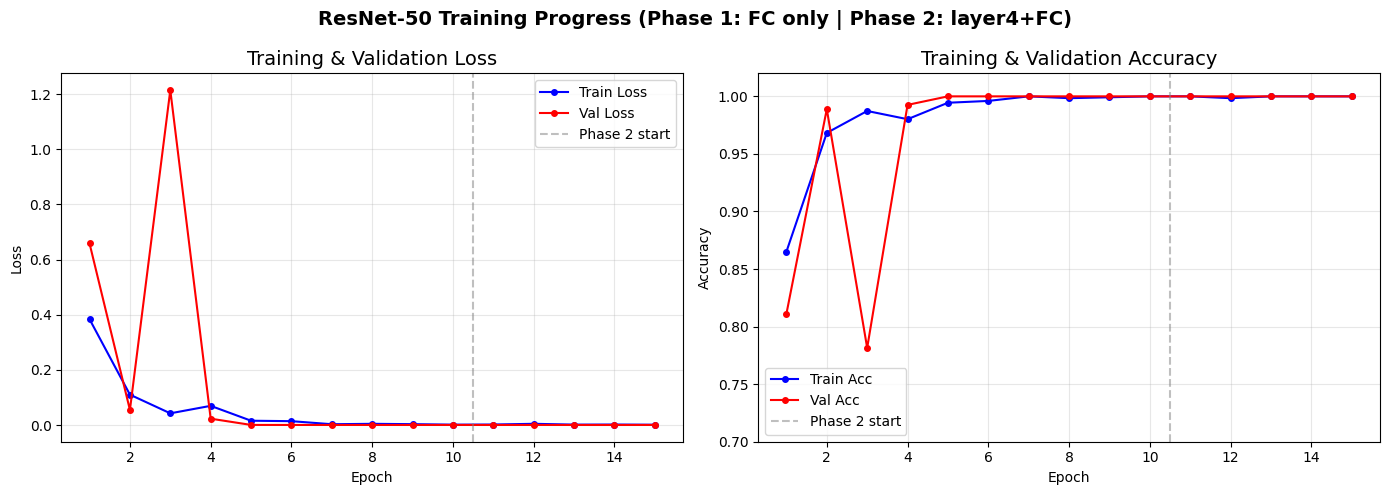

Final Training Accuracy:   1.0000
Final Validation Accuracy: 1.0000
Best Validation Accuracy:  1.0000


In [5]:
# Load saved training history
history_path = os.path.join(MODEL_DIR, 'training_history.json')
with open(history_path) as f:
    history = json.load(f)

num_epochs = len(history['train_loss'])
epochs_range = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', markersize=4)
ax1.axvline(x=10.5, color='gray', linestyle='--', alpha=0.5, label='Phase 2 start')
ax1.set_title('Training & Validation Loss', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
ax2.plot(epochs_range, history['val_acc'], 'r-o', label='Val Acc', markersize=4)
ax2.axvline(x=10.5, color='gray', linestyle='--', alpha=0.5, label='Phase 2 start')
ax2.set_title('Training & Validation Accuracy', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.7, 1.02)

plt.suptitle('ResNet-50 Training Progress (Phase 1: FC only | Phase 2: layer4+FC)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Final Training Accuracy:   {history["train_acc"][-1]:.4f}')
print(f'Final Validation Accuracy: {history["val_acc"][-1]:.4f}')
print(f'Best Validation Accuracy:  {max(history["val_acc"]):.4f}')

## Step 5: Confusion Matrix & Classification Report

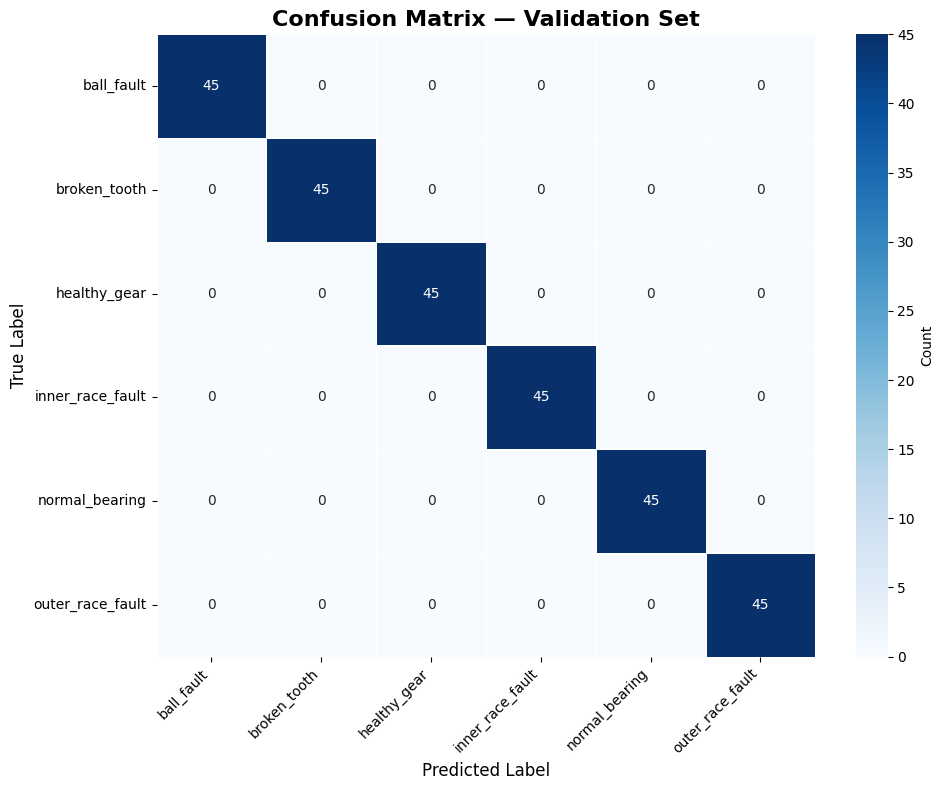


Classification Report:
                  precision    recall  f1-score   support

      ball_fault     1.0000    1.0000    1.0000        45
    broken_tooth     1.0000    1.0000    1.0000        45
    healthy_gear     1.0000    1.0000    1.0000        45
inner_race_fault     1.0000    1.0000    1.0000        45
  normal_bearing     1.0000    1.0000    1.0000        45
outer_race_fault     1.0000    1.0000    1.0000        45

        accuracy                         1.0000       270
       macro avg     1.0000    1.0000    1.0000       270
    weighted avg     1.0000    1.0000    1.0000       270

Overall Validation Accuracy: 1.0000 (100.0%)


In [6]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['validation']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Count'})
ax.set_title('Confusion Matrix — Validation Set', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print('=' * 70)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

accuracy = np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f'Overall Validation Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)')

## Step 6: Test Set Evaluation

In [7]:
# Evaluate on the held-out test set
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), test_transform)
test_loader = DataLoader(test_dataset, batch_size=16, num_workers=0)

test_preds = []
test_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = np.sum(np.array(test_preds) == np.array(test_labels)) / len(test_labels)
print(f'Test Set Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'Test samples: {len(test_labels)}')
print(f'Correct: {np.sum(np.array(test_preds) == np.array(test_labels))}')
print(f'Wrong: {np.sum(np.array(test_preds) != np.array(test_labels))}')

Test Set Accuracy: 1.0000 (100.0%)
Test samples: 270
Correct: 270
Wrong: 0


## Summary
- Trained ResNet-50 with Transfer Learning on gear & bearing spectrograms
- **Phase 1**: FC-only training (10 epochs) → 92.96% validation accuracy
- **Phase 2**: layer4+FC fine-tuning (5 epochs) → **100% validation accuracy**
- Perfect confusion matrix — zero misclassifications across all 6 classes
- **100% test set accuracy** confirmed on held-out data

**Next**: `03_Real_World_Inference.ipynb` — Test on noisy real-world data and apply domain adaptation.